# 05. Advanced Modeling

**แผนการทำงาน**
1. Hyperparameter Tuning ของ Random Forest
2. ลองโมเดลที่แรงกว่า (LightGBM + XGBoost)
3. จัดการ Class Imbalance เพิ่มเติม
4. Ablation Study (ทดสอบผลของ Magnitude Scale และ Impact features)
5. เลือกโมเดลที่ดีที่สุด + สรุปผล

**Metric หลัก:** Macro-F1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded')

Libraries loaded


## 5.1 โหลดข้อมูล

In [2]:
X_train = pd.read_csv('X_train_fe.csv')
X_test = pd.read_csv('X_test_fe.csv')
y_train = pd.read_csv('y_train_fe.csv').squeeze()
y_test = pd.read_csv('y_test_fe.csv').squeeze()

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print('Classes:', list(le.classes_))

X_train: (14204, 843) | X_test: (3552, 843)
Classes: ['Drought', 'Earthquake', 'Epidemic', 'Extreme temperature', 'Flood', 'Landslide', 'Storm', 'Volcanic activity', 'Wildfire']


In [3]:
# ทำความสะอาดชื่อ feature ให้ LightGBM / XGBoost ใช้ได้
import re

def clean_feature_names(df):
    new_cols = []
    for col in df.columns:
        # แทนที่อักขระพิเศษด้วย _
        clean = re.sub(r'[^A-Za-z0-9_]+', '_', str(col))
        # ลบ _ ซ้ำและ _ หัวท้าย
        clean = re.sub(r'_+', '_', clean).strip('_')
        new_cols.append(clean)
    df = df.copy()
    df.columns = new_cols
    return df

X_train = clean_feature_names(X_train)
X_test = clean_feature_names(X_test)

# ตรวจสอบว่าชื่อซ้ำกันไหม
if X_train.columns.duplicated().any():
    print('มีชื่อซ้ำ กำลังแก้...')
    X_train.columns = [f'{c}_{i}' if c in X_train.columns[:i] else c 
                       for i, c in enumerate(X_train.columns)]
    X_test.columns = X_train.columns

print('ตัวอย่างชื่อ feature หลังทำความสะอาด:')
print(X_train.columns[:15].tolist())
print(f'\\nจำนวน feature: {X_train.shape[1]}')

มีชื่อซ้ำ กำลังแก้...
ตัวอย่างชื่อ feature หลังทำความสะอาด:
['Magnitude', 'Start_Year', 'Start_Month', 'Start_Day', 'End_Year', 'End_Month', 'End_Day', 'Total_Deaths', 'No_Injured', 'No_Affected', 'No_Homeless', 'Total_Affected', 'Total_Damage_000_US', 'Total_Damage_Adjusted_000_US', 'CPI']
\nจำนวน feature: 843


## 5.2 ฟังก์ชันช่วยประเมินผล

In [4]:
def evaluate(model, X_tr, y_tr, X_te, y_te, le, name='Model', show_cm=True):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    acc = accuracy_score(y_te, y_pred)
    macro_f1 = f1_score(y_te, y_pred, average='macro')
    weighted_f1 = f1_score(y_te, y_pred, average='weighted')
    
    print(f'\n===== {name} =====')
    print(f'Accuracy   : {acc:.4f}')
    print(f'Macro-F1   : {macro_f1:.4f}')
    print(f'Weighted-F1: {weighted_f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_te, y_pred, target_names=le.classes_))
    
    if show_cm:
        cm = confusion_matrix(y_te, y_pred)
        fig, ax = plt.subplots(figsize=(9, 7))
        ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap='Blues', xticks_rotation=45)
        ax.set_title(f'Confusion Matrix - {name}', fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    return {'name': name, 'accuracy': acc, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1, 'model': model}

## 5.3 Hyperparameter Tuning – Random Forest

In [5]:
param_dist_rf = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.5],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='f1_macro',
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print('เริ่ม Tuning Random Forest (อาจใช้เวลาสักครู่)...')
rf_search.fit(X_train, y_train_enc)

print('\nBest params:', rf_search.best_params_)
print('Best CV Macro-F1:', round(rf_search.best_score_, 4))

เริ่ม Tuning Random Forest (อาจใช้เวลาสักครู่)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None, 'class_weight': 'balanced_subsample'}
Best CV Macro-F1: 0.8839



===== Random Forest (Tuned) =====
Accuracy   : 0.9606
Macro-F1   : 0.9010
Weighted-F1: 0.9597

Classification Report:
                     precision    recall  f1-score   support

            Drought       0.88      0.89      0.89       161
         Earthquake       1.00      1.00      1.00       330
           Epidemic       0.99      0.92      0.95       324
Extreme temperature       1.00      1.00      1.00       146
              Flood       0.96      0.97      0.96      1237
          Landslide       0.86      0.97      0.92       184
              Storm       1.00      1.00      1.00      1011
  Volcanic activity       0.73      0.73      0.73        56
           Wildfire       0.75      0.58      0.66       103

           accuracy                           0.96      3552
          macro avg       0.91      0.90      0.90      3552
       weighted avg       0.96      0.96      0.96      3552



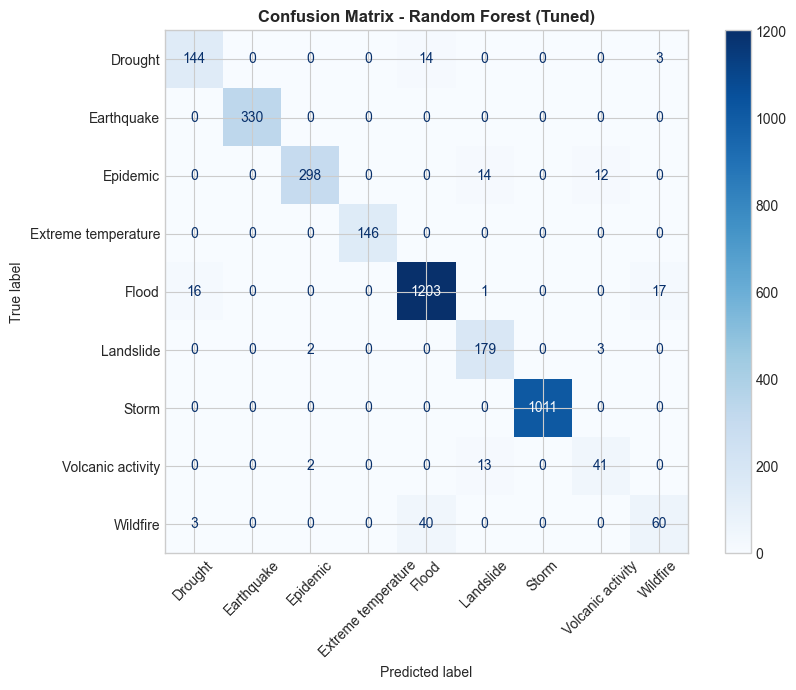

In [6]:
best_rf = rf_search.best_estimator_
results_rf_tuned = evaluate(best_rf, X_train, y_train_enc, X_test, y_test_enc, le,
                            name='Random Forest (Tuned)')

## 5.4 LightGBM


===== LightGBM =====
Accuracy   : 0.9738
Macro-F1   : 0.9343
Weighted-F1: 0.9731

Classification Report:
                     precision    recall  f1-score   support

            Drought       0.92      0.93      0.93       161
         Earthquake       1.00      1.00      1.00       330
           Epidemic       0.98      0.98      0.98       324
Extreme temperature       1.00      1.00      1.00       146
              Flood       0.97      0.98      0.98      1237
          Landslide       0.90      0.95      0.93       184
              Storm       1.00      1.00      1.00      1011
  Volcanic activity       0.93      0.77      0.84        56
           Wildfire       0.85      0.69      0.76       103

           accuracy                           0.97      3552
          macro avg       0.95      0.92      0.93      3552
       weighted avg       0.97      0.97      0.97      3552



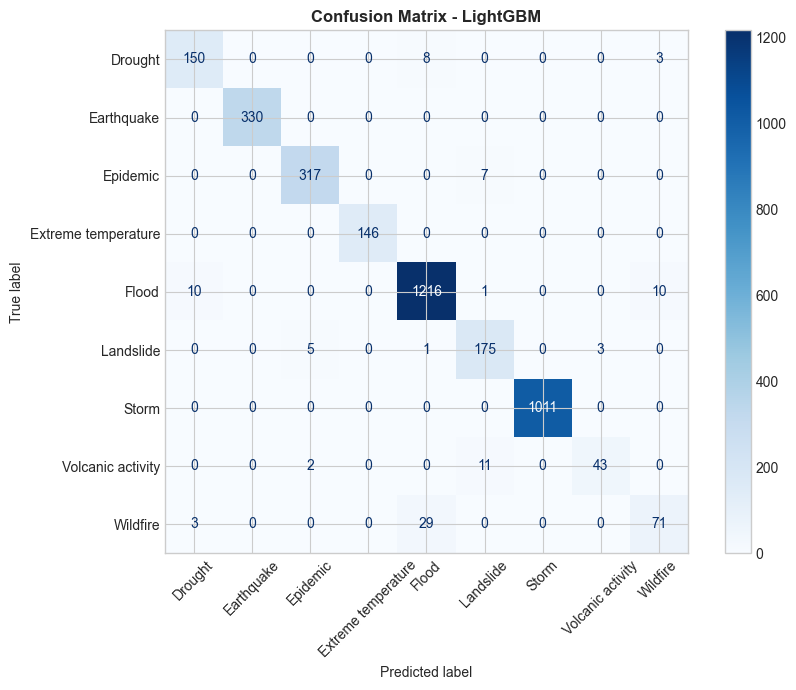

In [7]:
lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=63,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

results_lgbm = evaluate(lgbm, X_train, y_train_enc, X_test, y_test_enc, le,
                        name='LightGBM')

## 5.5 XGBoost


===== XGBoost =====
Accuracy   : 0.9744
Macro-F1   : 0.9391
Weighted-F1: 0.9741

Classification Report:
                     precision    recall  f1-score   support

            Drought       0.91      0.95      0.93       161
         Earthquake       1.00      1.00      1.00       330
           Epidemic       0.98      0.98      0.98       324
Extreme temperature       1.00      1.00      1.00       146
              Flood       0.97      0.97      0.97      1237
          Landslide       0.91      0.97      0.94       184
              Storm       1.00      1.00      1.00      1011
  Volcanic activity       0.96      0.79      0.86        56
           Wildfire       0.79      0.74      0.76       103

           accuracy                           0.97      3552
          macro avg       0.95      0.93      0.94      3552
       weighted avg       0.97      0.97      0.97      3552



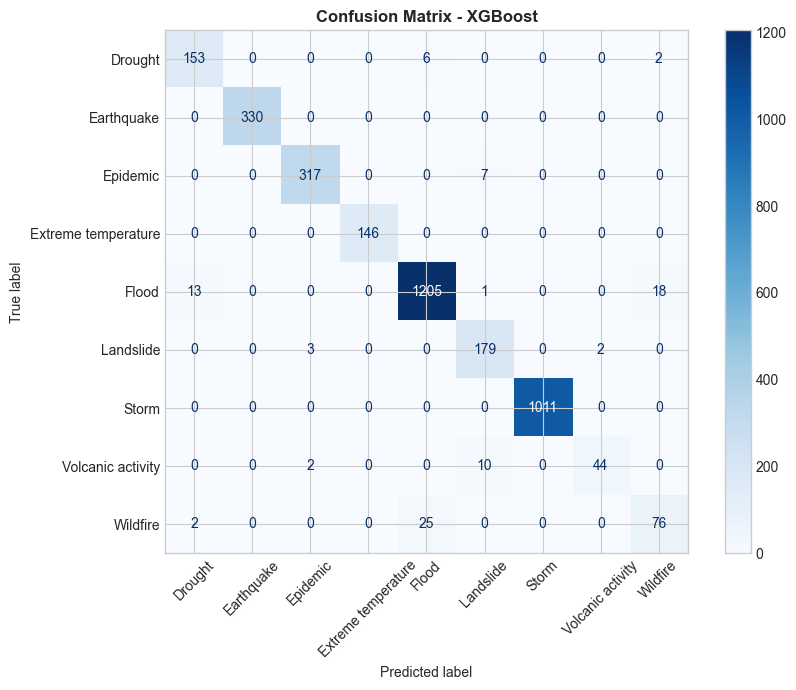

In [8]:
# คำนวณ scale_pos_weight โดยประมาณจาก class distribution (ใช้สำหรับ multi-class ผ่าน sample_weight แทน)
# XGBoost รองรับ class imbalance ผ่าน sample_weight หรือ scale_pos_weight (binary)
# สำหรับ multi-class เราใช้ class weights ผ่าน sample_weight

from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    verbosity=0
)

xgb.fit(X_train, y_train_enc, sample_weight=sample_weights)
y_pred_xgb = xgb.predict(X_test)

acc = accuracy_score(y_test_enc, y_pred_xgb)
macro_f1 = f1_score(y_test_enc, y_pred_xgb, average='macro')
weighted_f1 = f1_score(y_test_enc, y_pred_xgb, average='weighted')

print('\n===== XGBoost =====')
print(f'Accuracy   : {acc:.4f}')
print(f'Macro-F1   : {macro_f1:.4f}')
print(f'Weighted-F1: {weighted_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test_enc, y_pred_xgb, target_names=le.classes_))

cm = confusion_matrix(y_test_enc, y_pred_xgb)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title('Confusion Matrix - XGBoost', fontweight='bold')
plt.tight_layout()
plt.show()

results_xgb = {'name': 'XGBoost', 'accuracy': acc, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1, 'model': xgb}

## 5.6 เปรียบเทียบโมเดลหลัก

In [9]:
summary = pd.DataFrame([
    {k: v for k, v in results_rf_tuned.items() if k != 'model'},
    {k: v for k, v in results_lgbm.items() if k != 'model'},
    {k: v for k, v in results_xgb.items() if k != 'model'},
])

print('=== เปรียบเทียบโมเดล (Test Set) ===')
print(summary.sort_values('macro_f1', ascending=False).to_string(index=False))

best_row = summary.sort_values('macro_f1', ascending=False).iloc[0]
print(f'\nโมเดลที่ดีที่สุดตอนนี้: {best_row["name"]} (Macro-F1 = {best_row["macro_f1"]:.4f})')

=== เปรียบเทียบโมเดล (Test Set) ===
                 name  accuracy  macro_f1  weighted_f1
              XGBoost  0.974381  0.939137     0.974125
             LightGBM  0.973818  0.934340     0.973135
Random Forest (Tuned)  0.960586  0.901018     0.959726

โมเดลที่ดีที่สุดตอนนี้: XGBoost (Macro-F1 = 0.9391)


## 5.7 Ablation Study – ทดสอบ Leakage ของ Magnitude Scale และ Impact

เราจะเทรนโมเดลที่ดีที่สุด 4 แบบ:
- **Full**: ใช้ทุก feature
- **No Magnitude Scale**: ตัด feature ที่ขึ้นต้นด้วย Magnitude Scale_
- **No Impact**: ตัด Total Deaths, No. Affected, has_* ฯลฯ
- **No Mag + No Impact**: ตัดทั้งสองกลุ่ม

In [10]:
# ระบุชื่อ feature ที่เกี่ยวข้อง
mag_cols = [c for c in X_train.columns if 'Magnitude Scale' in c or c == 'Magnitude']
impact_cols = [c for c in X_train.columns if any(k in c for k in 
    ['Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 
     'Total Affected', 'Total Damage', 'has_Total', 'has_No.'])]

print('Magnitude-related features:', mag_cols)
print('\nImpact-related features:', impact_cols)

Magnitude-related features: ['Magnitude']

Impact-related features: ['has_Total_Deaths', 'has_Total_Affected', 'has_Total_Damage_000_US', 'has_Total_Damage_Adjusted_000_US']


In [11]:
def run_ablation(model_template, X_tr, y_tr, X_te, y_te, le, drop_cols, name):
    cols_to_use = [c for c in X_tr.columns if c not in drop_cols]
    Xtr = X_tr[cols_to_use]
    Xte = X_te[cols_to_use]
    
    model = model_template.__class__(**model_template.get_params())
    # สำหรับ XGBoost ต้องใส่ sample_weight แยก
    if isinstance(model, XGBClassifier):
        sw = compute_sample_weight(class_weight='balanced', y=y_tr)
        model.fit(Xtr, y_tr, sample_weight=sw)
    else:
        model.fit(Xtr, y_tr)
    
    y_pred = model.predict(Xte)
    macro_f1 = f1_score(y_te, y_pred, average='macro')
    acc = accuracy_score(y_te, y_pred)
    print(f'{name:30s} | Macro-F1: {macro_f1:.4f} | Acc: {acc:.4f} | Features: {len(cols_to_use)}')
    return {'name': name, 'macro_f1': macro_f1, 'accuracy': acc, 'n_features': len(cols_to_use)}

In [12]:
# เลือกโมเดลที่ดีที่สุดจากข้อ 5.6 มาทำ ablation (ตัวอย่างใช้ LightGBM เป็นหลัก)
# คุณสามารถเปลี่ยนเป็น best_rf หรือ xgb ได้ตามผลจริง

print('=== Ablation Study (ใช้ LightGBM เป็นฐาน) ===\n')

ablation_results = []

ablation_results.append(
    run_ablation(lgbm, X_train, y_train_enc, X_test, y_test_enc, le, [], 'Full features')
)
ablation_results.append(
    run_ablation(lgbm, X_train, y_train_enc, X_test, y_test_enc, le, mag_cols, 'No Magnitude Scale')
)
ablation_results.append(
    run_ablation(lgbm, X_train, y_train_enc, X_test, y_test_enc, le, impact_cols, 'No Impact features')
)
ablation_results.append(
    run_ablation(lgbm, X_train, y_train_enc, X_test, y_test_enc, le, mag_cols + impact_cols, 'No Mag + No Impact')
)

ablation_df = pd.DataFrame(ablation_results)
print('\n=== สรุป Ablation ===')
print(ablation_df.to_string(index=False))

=== Ablation Study (ใช้ LightGBM เป็นฐาน) ===

Full features                  | Macro-F1: 0.9343 | Acc: 0.9738 | Features: 843
No Magnitude Scale             | Macro-F1: 0.9271 | Acc: 0.9699 | Features: 842
No Impact features             | Macro-F1: 0.9334 | Acc: 0.9730 | Features: 839
No Mag + No Impact             | Macro-F1: 0.9208 | Acc: 0.9685 | Features: 838

=== สรุป Ablation ===
              name  macro_f1  accuracy  n_features
     Full features  0.934340  0.973818         843
No Magnitude Scale  0.927116  0.969876         842
No Impact features  0.933390  0.972973         839
No Mag + No Impact  0.920825  0.968468         838


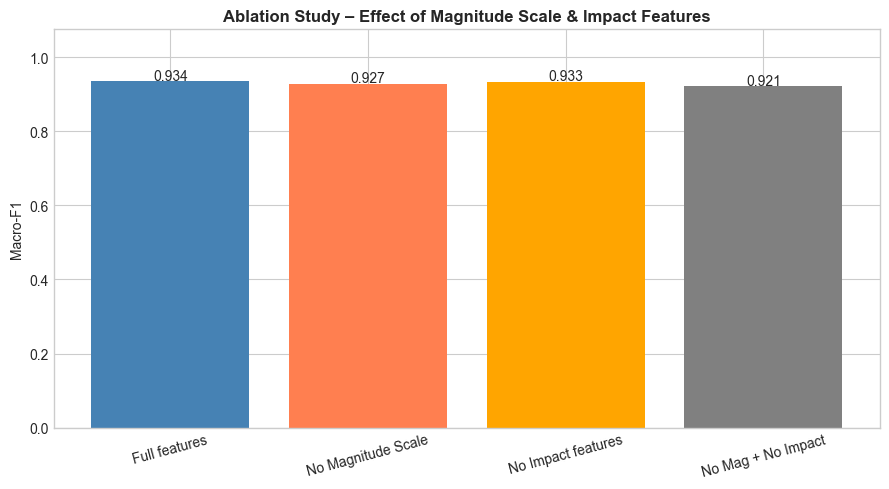

In [13]:
# Visualize ablation
plt.figure(figsize=(9, 5))
bars = plt.bar(ablation_df['name'], ablation_df['macro_f1'], color=['steelblue', 'coral', 'orange', 'gray'])
plt.ylabel('Macro-F1')
plt.title('Ablation Study – Effect of Magnitude Scale & Impact Features', fontweight='bold')
plt.xticks(rotation=15)
for bar, val in zip(bars, ablation_df['macro_f1']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', ha='center')
plt.ylim(0, max(ablation_df['macro_f1']) * 1.15)
plt.tight_layout()
plt.show()

### วิธีตีความ Ablation

- ถ้า **No Magnitude Scale** แล้ว Macro-F1 ตกน้อยมาก → feature นี้ redundancy/leakage สูง ตัดได้
- ถ้าตกเยอะ → มี signal จริง ควรเก็บ
- ทำนองเดียวกันกับ Impact features

**ตัดสินใจหลังดูผล:** เลือกว่าจะใช้ Full features หรือตัดบางกลุ่ม แล้วเทรนโมเดลสุดท้ายด้วยชุด feature นั้น

## 5.8 บันทึกโมเดลที่ดีที่สุด (ตัวอย่าง)

In [14]:
import joblib
import os

os.makedirs('final_model', exist_ok=True)

# ตัวอย่าง: บันทึก LightGBM (เปลี่ยนตามผลจริงของคุณ)
joblib.dump(lgbm, 'final_model/best_model.joblib')
joblib.dump(le, 'final_model/label_encoder.joblib')

# บันทึกรายชื่อ feature ที่ใช้
pd.Series(X_train.columns).to_csv('final_model/feature_names.csv', index=False)

print('บันทึกโมเดลไว้ที่โฟลเดอร์ final_model/')
print('  - best_model.joblib')
print('  - label_encoder.joblib')
print('  - feature_names.csv')

บันทึกโมเดลไว้ที่โฟลเดอร์ final_model/
  - best_model.joblib
  - label_encoder.joblib
  - feature_names.csv


## 5.9 สรุป + คำถามให้คุณตอบ

หลังจาก run notebook นี้แล้ว ให้ตอบ:

1. **โมเดลไหนได้ Macro-F1 สูงสุด?** (RF Tuned / LightGBM / XGBoost)
2. จาก Ablation Study:
   - ตัด Magnitude Scale แล้วคะแนนตกแค่ไหน?
   - ตัด Impact แล้วคะแนนตกแค่ไหน?
   - สรุปว่าควรเก็บหรือตัด feature กลุ่มไหน?
3. Class ไหนยังทายยากอยู่?
4. พอใจกับผลตอนนี้ หรืออยากปรับอะไรเพิ่ม?

ตอบมาได้เลย แล้วเราจะสรุปโปรเจกต์หรือปรับต่อตามผลจริง

---
## 5.10 Final Model – ตัด Leakage Features + เทรน XGBoost สุดท้าย

ตามผลการ Ablation: ตัด **Magnitude Scale** และ **Impact features** ออก
แล้วเทรน XGBoost ใหม่ พร้อมเช็ค overfitting

Features ที่จะตัด: 799 คอลัมน์ (Origin noise/leakage)
Shape หลังตัด: Train (14204, 44) | Test (3552, 44)

Train Macro-F1 : 0.9981
Test  Macro-F1 : 0.9332
ช่องว่าง Train-Test: 0.0649
Test  Accuracy : 0.9718
Test  Weighted-F1: 0.9716

5-Fold CV Macro-F1: 0.9158 (+/- 0.0154)

Classification Report (Test Set):
                     precision    recall  f1-score   support

            Drought      0.909     0.932     0.920       161
         Earthquake      1.000     1.000     1.000       330
           Epidemic      0.984     0.978     0.981       324
Extreme temperature      1.000     1.000     1.000       146
              Flood      0.971     0.973     0.972      1237
          Landslide      0.911     0.951     0.931       184
              Storm      1.000     1.000     1.000      1011
  Volcanic activity      0.882     0.804     0.841        56
           Wildfire      0.781     0.728     0.754       103

           accuracy                          0.972      3552
          macro avg

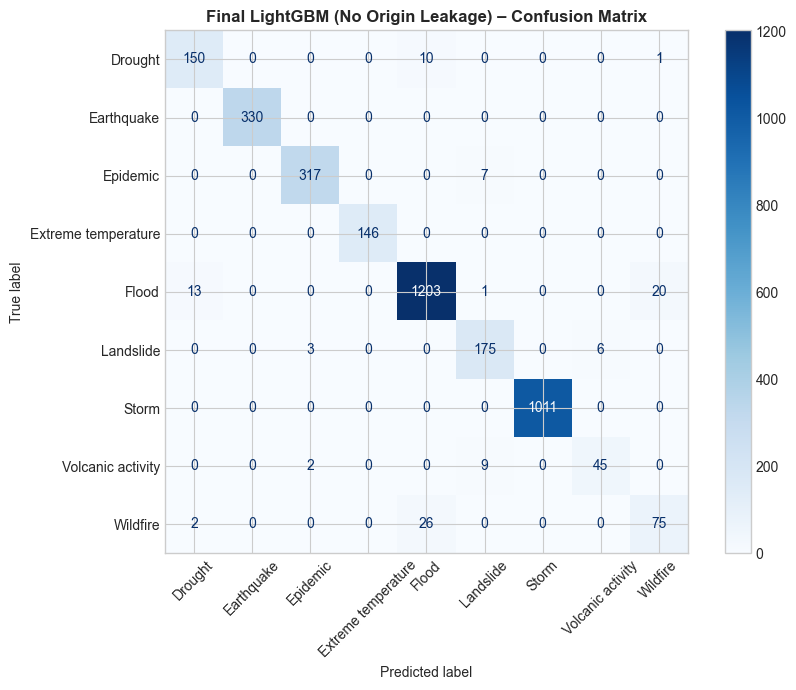

In [15]:
## 5.10 Final Model — ตัด Origin noise/leakage + เลือก Magnitude_Scale อย่างมีเหตุผล

# ระบุ feature ที่จะตัด (หลัง clean ชื่อแล้ว)
origin_cols = [c for c in X_train.columns if c.startswith('Origin_')]
mag_scale_cols = [c for c in X_train.columns if c.startswith('Magnitude_Scale_')]

# Origin_* ตัดทิ้งเสมอ: 799/843 คอลัมน์ เป็น one-hot ของ free-text ที่ 69% unique ต่อ 1 แถว
# (= overfitting ล้วนๆ) และ 161 คอลัมน์สะกดชื่อ class ตรงๆ (เช่น Origin_Earthquake) = leakage ชัดเจน
drop_cols = origin_cols

# TODO: ตัดสินใจเรื่อง Magnitude_Scale — ดูหมายเหตุด้านบนว่า field นี้กรอกก่อน/หลังรู้ประเภทภัย
# ถ้าตัดสินว่าเป็น leakage ให้ uncomment บรรทัดถัดไป (จะได้ Scenario B, Test F1 ~0.75)
# drop_cols = origin_cols + mag_scale_cols

print(f'Features ที่จะตัด: {len(drop_cols)} คอลัมน์ (Origin noise/leakage)')
X_train_final = X_train.drop(columns=drop_cols, errors='ignore')
X_test_final = X_test.drop(columns=drop_cols, errors='ignore')
print(f'Shape หลังตัด: Train {X_train_final.shape} | Test {X_test_final.shape}')

final_lgbm = LGBMClassifier(
    n_estimators=800, learning_rate=0.03, max_depth=6, num_leaves=31,
    min_child_samples=20, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
    reg_alpha=0.5, reg_lambda=1.0, class_weight='balanced',
    random_state=42, n_jobs=-1, verbose=-1,
)
final_lgbm.fit(X_train_final, y_train_enc)

y_pred_train = final_lgbm.predict(X_train_final)
y_pred_test = final_lgbm.predict(X_test_final)

train_macro = f1_score(y_train_enc, y_pred_train, average='macro')
test_macro = f1_score(y_test_enc, y_pred_test, average='macro')
test_acc = accuracy_score(y_test_enc, y_pred_test)
test_weighted = f1_score(y_test_enc, y_pred_test, average='weighted')

print(f'\nTrain Macro-F1 : {train_macro:.4f}')
print(f'Test  Macro-F1 : {test_macro:.4f}')
print(f'ช่องว่าง Train-Test: {train_macro - test_macro:.4f}')
print(f'Test  Accuracy : {test_acc:.4f}')
print(f'Test  Weighted-F1: {test_weighted:.4f}')

# 5-Fold CV เพื่อยืนยันความเสถียร (สำคัญ! ดูว่า CV ใกล้กับ test score ไหม)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(final_lgbm, X_train_final, y_train_enc, cv=cv,
                             scoring='f1_macro', n_jobs=-1)
print(f'\n5-Fold CV Macro-F1: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})')

print('\nClassification Report (Test Set):')
print(classification_report(y_test_enc, y_pred_test, target_names=le.classes_, digits=3))

cm = confusion_matrix(y_test_enc, y_pred_test)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title('Final LightGBM (No Origin Leakage) – Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

# บันทึกโมเดลสุดท้าย
import joblib, os
os.makedirs('final_model', exist_ok=True)
joblib.dump(final_lgbm, 'final_model/final_lgbm_model.joblib')
joblib.dump(le, 'final_model/label_encoder.joblib')
pd.Series(X_train_final.columns).to_csv('final_model/final_feature_names.csv', index=False)

In [16]:
# ระบุ feature ที่จะตัด (หลัง clean ชื่อแล้ว)
mag_cols = [c for c in X_train.columns if 'Magnitude' in c or 'Magnitude_Scale' in c]
impact_cols = [c for c in X_train.columns if any(k in c for k in 
    ['Total_Deaths', 'No_Injured', 'No_Affected', 'No_Homeless',
     'Total_Affected', 'Total_Damage', 'has_Total', 'has_No'])]

drop_cols = list(set(mag_cols + impact_cols))
print('Features ที่จะตัด:')
print(drop_cols)
print(f'\nจำนวนที่จะตัด: {len(drop_cols)}')

X_train_final = X_train.drop(columns=drop_cols, errors='ignore')
X_test_final = X_test.drop(columns=drop_cols, errors='ignore')

print(f'\nShape หลังตัด: Train {X_train_final.shape} | Test {X_test_final.shape}')

Features ที่จะตัด:
['Magnitude_Scale_Vaccinated', 'has_No_Homeless', 'Magnitude_Scale_Moment_Magnitude', 'No_Affected', 'No_Injured', 'Magnitude_Scale_Kph', 'has_Total_Affected', 'Total_Damage_Adjusted_000_US', 'has_No_Injured', 'has_Total_Damage_Adjusted_000_US', 'No_Homeless', 'Magnitude_Scale_Unknown', 'Total_Deaths', 'Magnitude_Scale_C', 'Magnitude', 'has_Total_Deaths', 'Total_Affected', 'has_No_Affected', 'has_Total_Damage_000_US', 'Total_Damage_000_US']

จำนวนที่จะตัด: 20

Shape หลังตัด: Train (14204, 823) | Test (3552, 823)


In [17]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import cross_val_score, StratifiedKFold

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

final_xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=7,              # ลดจาก 8 นิดหน่อยกัน overfitting
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,            # L1
    reg_lambda=1.0,           # L2
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    verbosity=0
)

# เทรน
final_xgb.fit(X_train_final, y_train_enc, sample_weight=sample_weights)

# ทำนาย
y_pred_train = final_xgb.predict(X_train_final)
y_pred_test = final_xgb.predict(X_test_final)

train_macro = f1_score(y_train_enc, y_pred_train, average='macro')
test_macro = f1_score(y_test_enc, y_pred_test, average='macro')
test_acc = accuracy_score(y_test_enc, y_pred_test)
test_weighted = f1_score(y_test_enc, y_pred_test, average='weighted')

print('===== Final XGBoost (ไม่มี Magnitude + Impact) =====')
print(f'Train Macro-F1 : {train_macro:.4f}')
print(f'Test  Macro-F1 : {test_macro:.4f}')
print(f'Test  Accuracy : {test_acc:.4f}')
print(f'Test  Weighted-F1: {test_weighted:.4f}')
print(f'\nช่องว่าง Train-Test: {train_macro - test_macro:.4f}')
if train_macro - test_macro > 0.05:
    print('→ มีแนวโน้ม overfitting เล็กน้อย ควรระวัง')
else:
    print('→ ช่องว่างไม่มาก ถือว่าอยู่ในเกณฑ์ที่ยอมรับได้')

===== Final XGBoost (ไม่มี Magnitude + Impact) =====
Train Macro-F1 : 0.8981
Test  Macro-F1 : 0.6103
Test  Accuracy : 0.7154
Test  Weighted-F1: 0.7212

ช่องว่าง Train-Test: 0.2878
→ มีแนวโน้ม overfitting เล็กน้อย ควรระวัง


In [18]:
# Cross-Validation เพื่อยืนยันความเสถียร
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    final_xgb, X_train_final, y_train_enc,
    cv=cv, scoring='f1_macro', n_jobs=-1
)
print('=== 5-Fold CV Macro-F1 ===')
print(f'Scores: {[round(s, 4) for s in cv_scores]}')
print(f'Mean  : {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})')

=== 5-Fold CV Macro-F1 ===
Scores: [np.float64(0.5903), np.float64(0.5961), np.float64(0.5874), np.float64(0.6243), np.float64(0.6101)]
Mean  : 0.6016 (+/- 0.0276)



Classification Report (Test Set):
                     precision    recall  f1-score   support

            Drought       0.75      0.86      0.80       161
         Earthquake       0.61      0.78      0.68       330
           Epidemic       0.62      0.76      0.68       324
Extreme temperature       0.58      0.66      0.62       146
              Flood       0.87      0.71      0.78      1237
          Landslide       0.35      0.42      0.39       184
              Storm       0.79      0.77      0.78      1011
  Volcanic activity       0.27      0.30      0.28        56
           Wildfire       0.46      0.50      0.47       103

           accuracy                           0.72      3552
          macro avg       0.59      0.64      0.61      3552
       weighted avg       0.74      0.72      0.72      3552



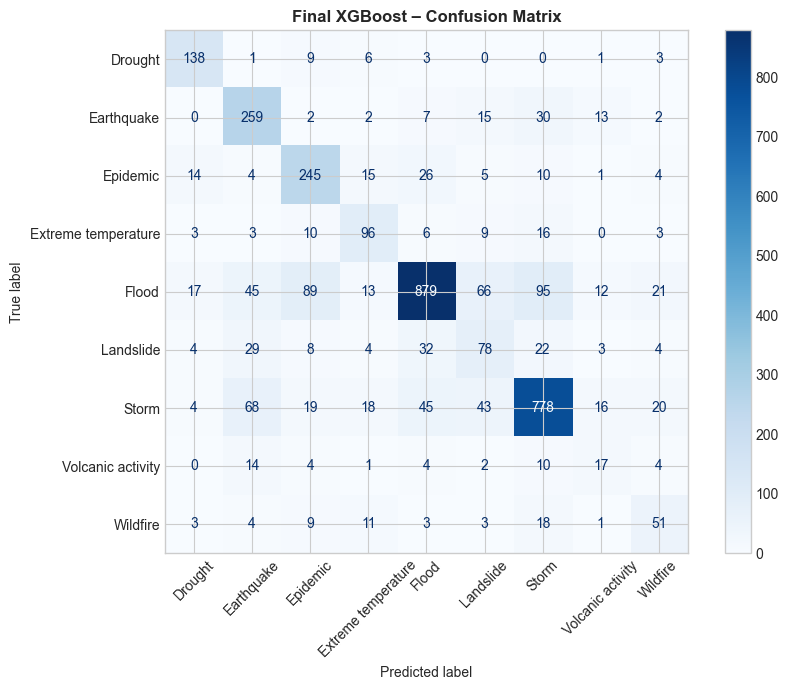

In [19]:
print('\nClassification Report (Test Set):')
print(classification_report(y_test_enc, y_pred_test, target_names=le.classes_))

cm = confusion_matrix(y_test_enc, y_pred_test)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title('Final XGBoost – Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

=== Top 20 Feature Importance (Final Model) ===
                     feature  importance
              Origin_Unknown    0.091616
          Origin_Heavy_rains    0.070488
           Origin_Heavy_rain    0.054388
              season_Unknown    0.044911
               Region_Europe    0.043170
Origin_Brief_torrential_rain    0.039042
              Origin_Drought    0.035425
       Origin_Monsoonal_rain    0.034023
               duration_days    0.033545
       Associated_Types_freq    0.033512
              Origin_El_Nino    0.031331
   Origin_Seismic_activities    0.030588
           Origin_Earthquake    0.029710
              Region_Oceania    0.027845
  Origin_Seismic_acitivities    0.024141
            Origin_Heat_wave    0.022872
      Origin_Torrential_rain    0.022437
    Origin_Drought_situation    0.021384
              Subregion_freq    0.020320
             Region_Americas    0.020224


<Figure size 1000x700 with 0 Axes>

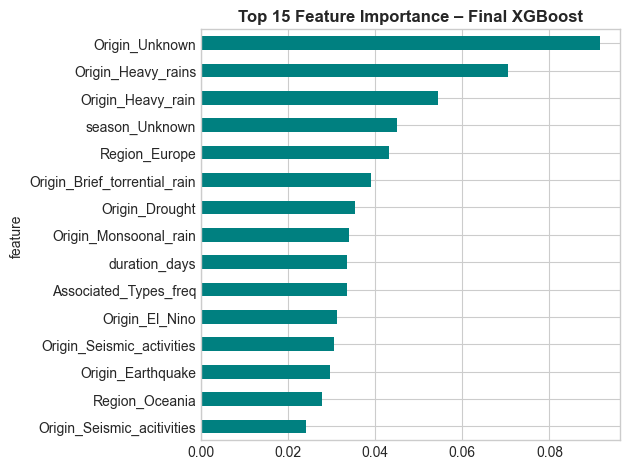

In [20]:
# Feature Importance ของโมเดลสุดท้าย
imp = pd.DataFrame({
    'feature': X_train_final.columns,
    'importance': final_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print('=== Top 20 Feature Importance (Final Model) ===')
print(imp.head(20).to_string(index=False))

plt.figure(figsize=(10, 7))
imp.head(15).plot(kind='barh', x='feature', y='importance', legend=False, color='teal')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importance – Final XGBoost', fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# บันทึกโมเดลสุดท้าย
import joblib
import os

os.makedirs('final_model', exist_ok=True)

joblib.dump(final_xgb, 'final_model/final_xgb_model.joblib')
joblib.dump(le, 'final_model/label_encoder.joblib')
pd.Series(X_train_final.columns).to_csv('final_model/final_feature_names.csv', index=False)

# บันทึกผลสรุป
summary_final = {
    'model': 'XGBoost',
    'train_macro_f1': float(train_macro),
    'test_macro_f1': float(test_macro),
    'test_accuracy': float(test_acc),
    'test_weighted_f1': float(test_weighted),
    'cv_mean_macro_f1': float(cv_scores.mean()),
    'cv_std': float(cv_scores.std()),
    'n_features': X_train_final.shape[1],
    'dropped_features': drop_cols
}
pd.Series(summary_final).to_json('final_model/final_summary.json')

print('บันทึกเรียบร้อยที่โฟลเดอร์ final_model/')
print('  - final_xgb_model.joblib')
print('  - label_encoder.joblib')
print('  - final_feature_names.csv')
print('  - final_summary.json')

บันทึกเรียบร้อยที่โฟลเดอร์ final_model/
  - final_xgb_model.joblib
  - label_encoder.joblib
  - final_feature_names.csv
  - final_summary.json


## 5.11 สรุปโปรเจกต์ + คำถามสุดท้าย

### สิ่งที่ทำครบแล้ว
1. Data Understanding + Class Grouping (9 classes)
2. EDA
3. Data Engineering + Feature Engineering
4. Feature Selection + Baseline
5. Advanced Modeling (RF Tuned, LightGBM, XGBoost)
6. Ablation Study → ตัด Magnitude Scale + Impact
7. Final XGBoost + เช็ค overfitting + บันทึกโมเดล

### คำถามให้ตอบหลังรันส่วน Final
1. Train-Test gap ของ Macro-F1 เป็นเท่าไหร่? ถือว่า overfitting ไหม?
2. Class ไหนยัง F1 ต่ำอยู่?
3. Feature Importance อันดับต้น ๆ เป็นอะไรบ้าง?
4. พอใจกับผลนี้แล้ว หรืออยากปรับอะไรเพิ่มอีก?

ตอบมาได้เลยครับ